#### This is the  notebook which  contains all Level 2 tasks from my Cognifyz internship project.

In [1]:
# Now we are agin simplay importing the libreries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

# Loading the dataset
df = pd.read_csv('Dataset  (1).csv')

df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


#### Task 1 - Restaurant Ratings

- Now we need to Analyze the distribution of aggregate ratings and determine the most common rating range

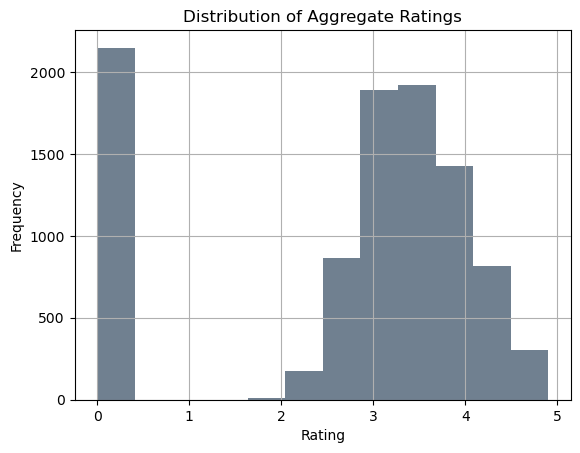

In [3]:
# now we are going to plot a simple histograme to see the distribution of thr aggregate ratting.
df['Aggregate rating'].hist(bins=12,color='slategray')
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

Most Common Rating Range:
Aggregate rating
(3, 4]    4388
(2, 3]    1891
(4, 5]    1114
(1, 2]      10
(0, 1]       0
Name: count, dtype: int64


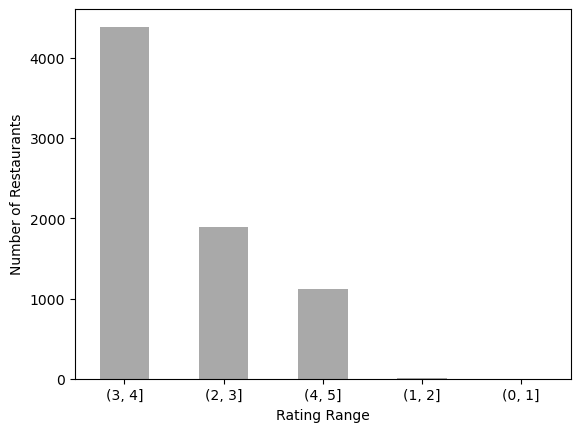

In [4]:
# Now we will see the most common ratting range
rating_range = pd.cut(df['Aggregate rating'], bins=[0,1,2,3,4,5])
print('='*30)
print("Most Common Rating Range:")
print('='*30)
print(rating_range.value_counts())
print('='*30)

rating_range.value_counts().plot(kind='bar', color='darkgray')
plt.xlabel("Rating Range")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=360)
plt.show()


In [5]:

# Now we need to  find the avg no of votes for the restaurants in the dataset.
avg_votes = df['Votes'].mean()

print('='*30)
print("\nAverage Number of Votes:")
print('-'*30)
print(avg_votes)
print('='*30)


Average Number of Votes:
------------------------------
156.909747670401


#### Task 2 - Cuisine Combination

- Now we need to Identify the most common combinations of cuisines in the dataset.

In [6]:
# now we see the most common cuisine combinations in our dataset
combo = df['Cuisines'].value_counts().head(10)
print('='*30)
print("Most Common Cuisine Combinations:")
print('-'*30)
print(combo)
print('='*30)


Most Common Cuisine Combinations:
------------------------------
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


- Determine if certain cuisine combinations tend to have higher ratings.

In [7]:

# Ratings for cuisine combinations in our dataset
combo_rating = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)
print('='*50)
print("\nCuisine Combinations with Highest Ratings:")
print('-'*50)
print(combo_rating.head(10))
print('='*50)



Cuisine Combinations with Highest Ratings:
--------------------------------------------------
Cuisines
Italian, Deli               4.9
Hawaiian, Seafood           4.9
American, Sandwich, Tea     4.9
Continental, Indian         4.9
European, Asian, Indian     4.9
European, Contemporary      4.9
European, German            4.9
BBQ, Breakfast, Southern    4.9
American, Coffee and Tea    4.9
Sunda, Indonesian           4.9
Name: Aggregate rating, dtype: float64


#### Task 3 - Geographic Analysis

- Now we need to Determine if certain cuisine combinations tend to have higher ratings.

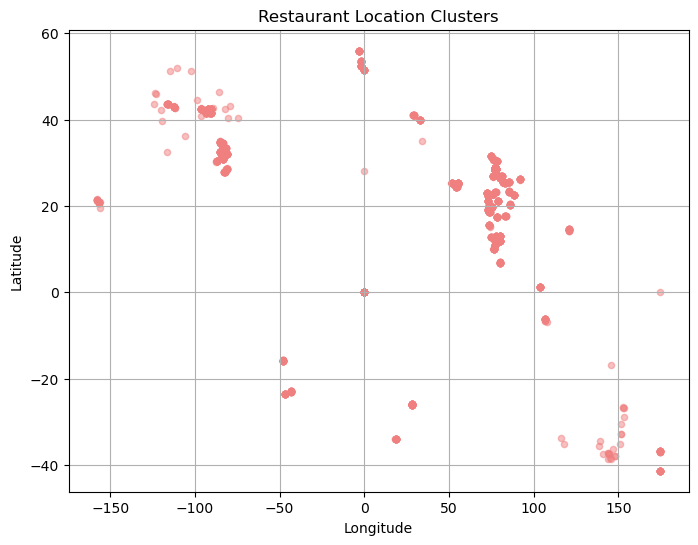

Dense groups of points indicate restaurant clusters in specific areas.


In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    alpha=0.5,
    color='lightcoral',
    s=20
)

plt.title('Restaurant Location Clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.grid(True)

plt.show()

print("Dense groups of points indicate restaurant clusters in specific areas.")

#### Task 4 - Restaurant Chains

- Identify if there are any restaurant chains present in the dataset.

In [9]:
# Find restaurant chains
chains = df['Restaurant Name'].value_counts()

restaurant_chains = chains[chains > 1]
print('='*30)
print("Restaurant Chains:")
print('-'*30)
print(restaurant_chains.head(10))
print('='*30)

Restaurant Chains:
------------------------------
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


- Now we need to Analyze the ratings and popularity of different restaurant chains

In [10]:

# Analyze ratings and popularity
chain_analysis = df.groupby('Restaurant Name')[['Aggregate rating', 'Votes']].mean()
print('='*30)
print("Top Chains by Rating and Votes:")
print('-'*30)
print(chain_analysis.loc[restaurant_chains.index].sort_values(by='Votes', ascending=False).head(10))
print('='*30)

Top Chains by Rating and Votes:
------------------------------
                           Aggregate rating        Votes
Restaurant Name                                         
Truffles                           3.950000  4841.000000
Joey's Pizza                       4.250000  3903.500000
AB's - Absolute Barbecues          4.825000  3350.000000
Big Chill                          4.475000  2713.250000
Big Yellow Door                    4.266667  2503.666667
Out Of The Box                     3.850000  2450.000000
Saravana Bhavan                    4.133333  2412.666667
Olive Bistro                       4.150000  1854.000000
Talaga Sampireun                   4.900000  1838.000000
SpiceKlub                          4.300000  1825.500000
